# Korean Air's AI-Powered Drone Swarms: Multi-Agent Reinforcement Learning for MRO Inspection

## Introduction

At Drone Show Korea 2026, Asia's largest drone exhibition held at BEXCO in Busan, Korean Air unveiled a full lineup of AI-powered unmanned aerial vehicles (UAVs) and advanced air mobility (AAM) technologies [1][2]. Among the most notable displays were swarm-based drone solutions designed for maintenance, repair, and overhaul (MRO) inspection of aircraft. The airline also showcased ACROSS (Air Control and Routing Orchestrated Skyway System), its in-house air traffic management platform, alongside a mock-up eVTOL aircraft from partner Archer Aviation [3].

Aircraft MRO inspection is traditionally manual, time-consuming, and expensive. Technicians walk around the aircraft to visually check for damage on the fuselage, wings, and control surfaces. This process can take hours and is subject to human fatigue and inconsistency. Drone swarms offer a compelling alternative: multiple small drones can simultaneously scan different sections of the aircraft, reducing inspection time and improving coverage consistency. But coordinating several drones to efficiently divide up the work without collisions or redundant coverage is a non-trivial problem.

In this notebook, we demonstrate how **multi-agent reinforcement learning (MARL)** can train a swarm of 5 drones to cooperatively inspect an aircraft fuselage. Each drone learns independently through trial-and-error to cover its portion of the surface, avoid collisions with other drones, and complete the inspection as quickly as possible. The entire demo runs in pure Python with no GPU required.

## Environment Setup

This demo runs on a Mac with an M-series chip.

**Prerequisite:**
Install [Miniconda](https://www.anaconda.com/docs/getting-started/miniconda/install).

**Terminal commands to create the environment:**
```bash
# Create and activate the conda environment
conda create -n drone-inspection python=3.10 -y
conda activate drone-inspection

# Install core libraries
conda install -c conda-forge numpy matplotlib seaborn jupyter jupyterlab ipython ipykernel pillow -y
pip install pymupdf

# Register the kernel
python -m ipykernel install --user --name drone-inspection --display-name "Python (drone-inspection)"

# Clear cache
conda clean -a -y && pip cache purge
```

In [1]:
# Standard libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# RL-specific
from collections import defaultdict

# Display utilities
import pymupdf as fitz
from IPython.display import Image as IPythonImage
from IPython.display import display, SVG, HTML

In [2]:
# Utility function to display image (png, jpg, pdf, svg) in Jupyter
def show_image(image_path, width=500, page_num=0, dpi=300):
    if image_path.lower().endswith('.pdf'):
        doc = fitz.open(image_path)
        page = doc.load_page(page_num)
        pix = page.get_pixmap(dpi=dpi)
        img_data = pix.tobytes("png")
        doc.close()
        display(IPythonImage(data=img_data, width=width))
    elif image_path.lower().endswith('.svg'):
        display(SVG(image_path))
    else:
        display(IPythonImage(filename=image_path, width=width))

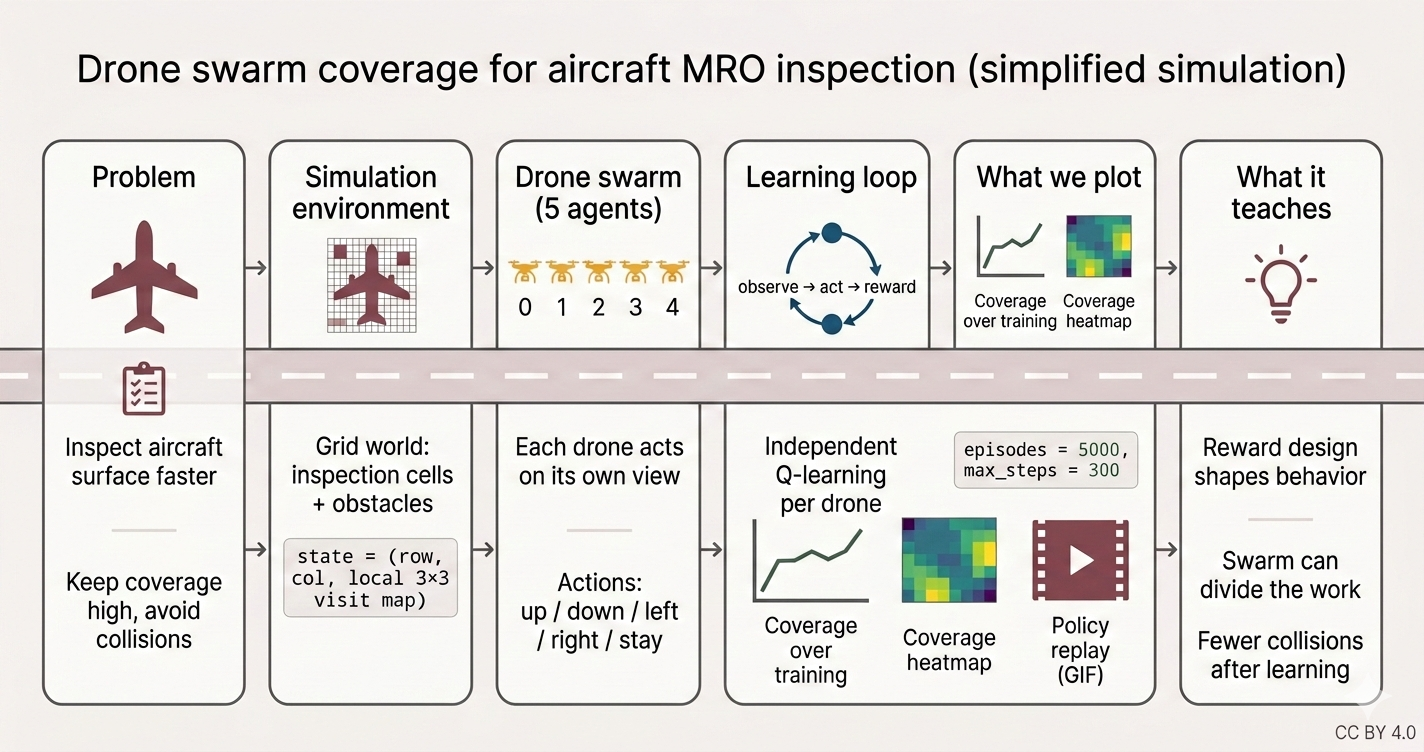

In [3]:
show_image('assets/pipeline-dev.png', width=900)

**Figure:** End-to-end view of this demo. We start with a simplified aircraft inspection problem, train a small drone swarm in simulation with rewards for new coverage and penalties for collisions and wasted steps, then evaluate with replay, heatmaps, and learning curves to check whether the swarm learned to split up the work.


## What is Multi-Agent Reinforcement Learning?

### Reinforcement learning in a nutshell

Reinforcement learning (RL) is a type of machine learning where an **agent** learns to make decisions by interacting with an **environment**. At each time step, the agent observes the current **state** of the environment, chooses an **action**, and receives a **reward** signal that tells it how good or bad that action was. Over many rounds of trial and error, the agent learns a **policy** (a strategy that maps states to actions) that maximizes its total reward over time.

Think of it like training a search-and-rescue dog. You drop the dog into a field and it picks a direction to explore. When it finds something useful (a target scent), it gets a treat. When it wastes time or wanders in circles, it gets nothing. Over many training sessions, the dog learns which areas to search first and how to navigate obstacles efficiently. Nobody gives the dog a step-by-step map. It figures out the best strategy from experience.

### From one agent to many

Standard RL works well for a single agent. But what happens when you have 5 drones that all need to inspect the same aircraft? Each drone is its own agent, and they all share the same environment (the aircraft fuselage). This is **multi-agent reinforcement learning (MARL)**.

The challenge is coordination. If all 5 drones rush to the same section, they waste time covering the same area and risk colliding. If they spread out but leave gaps, parts of the aircraft go unchecked. The drones need to learn to divide the work, without anyone explicitly telling them who goes where.

One straightforward approach is **Independent Q-Learning (IQL)**: each drone maintains its own Q-table and learns as if it were acting alone, even though the environment is shared. The "Q" stands for quality. $Q(s, a)$ represents how good it is to take action $a$ in state $s$. Each drone updates its Q-values using the standard update rule:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \Big[ r + \gamma \max_{a'} Q(s',a') - Q(s,a) \Big]$$

where:
- $\alpha$ is the **learning rate** (how much new information overrides old estimates, set to 0.1),
- $r$ is the **reward** received after taking action $a$,
- $\gamma$ is the **discount factor** (how much the agent values future rewards vs. immediate ones, set to 0.95),
- $s'$ is the **next state** after taking the action, and
- $\max_{a'} Q(s', a')$ is the best estimated future value from the next state.

In plain terms: the drone looks at how much reward it just got, adds its best guess of future rewards, and adjusts its current estimate accordingly. Over thousands of episodes, the Q-values converge and the drones settle on effective strategies.

### Why does this work for drone swarms?

Even though each drone learns independently, coordination can emerge naturally. When one drone consistently covers a particular region, the other drones find fewer unvisited cells there and get less reward for going to that area. Over time, each drone gravitates toward its own "territory." This is implicit coordination through shared environment dynamics rather than explicit communication.

We will also test a **cooperative reward variant** where each drone gets a small bonus whenever *any* drone visits a new cell. This encourages the drones to care about the swarm's overall progress, not just their own. Comparing the two approaches shows how reward design shapes emergent group behavior.

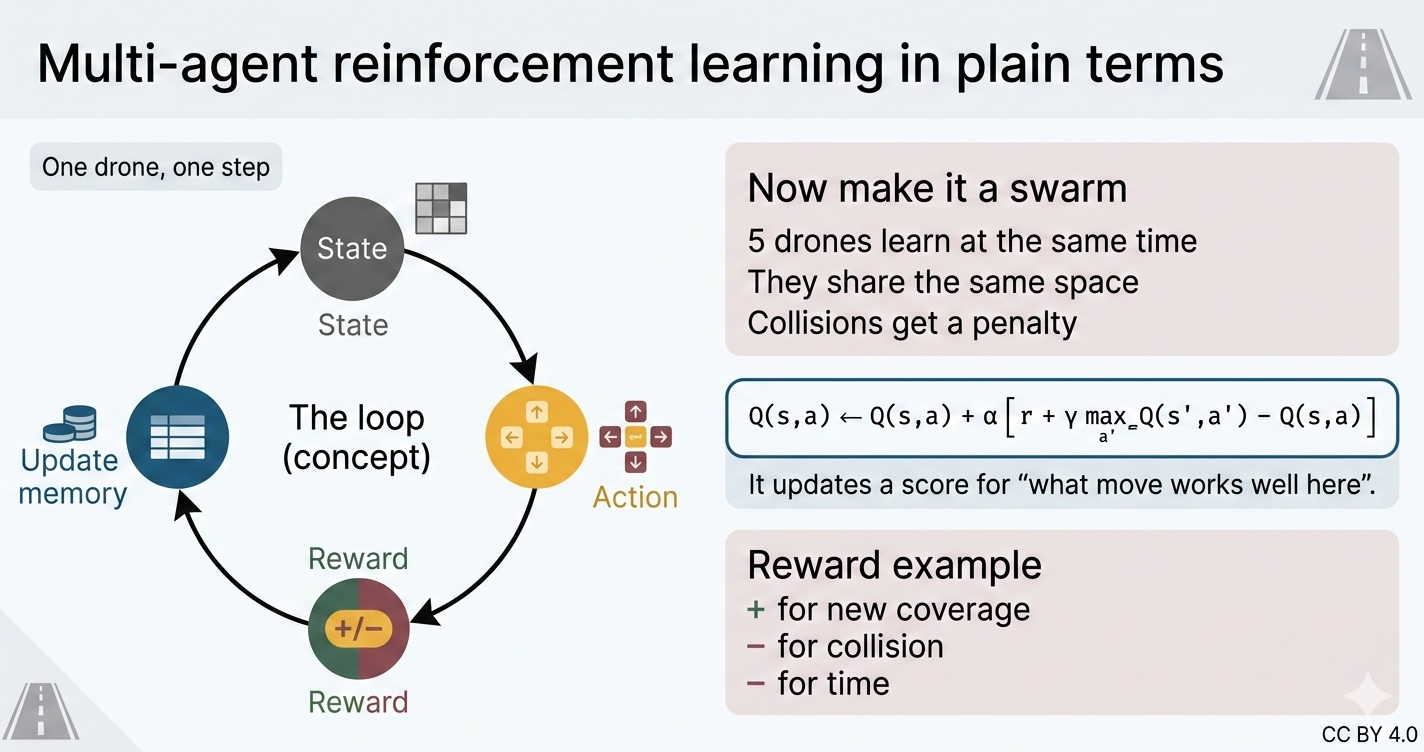

In [4]:
show_image('assets/aitheory-dev.png', width=900)

**Figure:** Multi-agent reinforcement learning in plain words. Each drone repeats a loop: it sees its local situation, picks a move, gets a reward, and updates its memory. With several drones sharing the same space, the reward is what makes them learn to cover new areas while avoiding collisions.


## Drone Inspection Environment

> **DISCLAIMER**: This environment is a **simplified simulation** for educational purposes. The grid layout, obstacle positions, and drone behavior are approximations based on general aircraft geometry. This does not represent actual Korean Air MRO procedures or real drone flight data.

### Grid design and state representation

We model the aircraft fuselage as a 20-row by 22-column grid, viewed from above. The silhouette is shaped like an actual aircraft: a pointed nose (rows 0-3) that widens into swept wings spanning the full grid width (rows 5-11), a narrow aft fuselage (rows 12-14), a horizontal stabilizer at the tail (rows 15-17), and a tapered tail tip (rows 18-19). About 65% of cells are **inspection zones** that the drones need to visit. The rest are either outside the aircraft boundary or **obstacles**: engine nacelles on the wings, a nose landing gear near the cockpit, main landing gear under the aft fuselage, and a no-fly zone around the vertical stabilizer at the tail.

Five drones start at spread-out positions across the aircraft: near the cockpit, on opposite wings, at the center fuselage, and on the horizontal stabilizer. Each time step, every drone picks one of five actions (up, down, left, right, or stay). If a move would go off the grid or into an obstacle, the drone stays put. If two drones try to enter the same cell at the same time, both get a penalty and neither moves.

Each drone only sees its own position and the visit status of its immediate 3x3 neighborhood (9 cells around it). This local view keeps the state space small enough for tabular Q-learning to work. The full state for a drone is `(row, col, 9-bit neighborhood status)`, which gives roughly 225,000 possible states per drone. If we used a global view of the entire grid instead, the state space would blow up to billions and Q-learning would never converge. An episode ends when every inspection zone has been visited or after 300 time steps, whichever comes first.

In [3]:
class DroneInspectionEnv:
    """Multi-agent grid environment for aircraft MRO drone inspection."""

    def __init__(self, n_drones=5, max_steps=300):
        self.rows, self.cols = 20, 22
        self.n_drones = n_drones
        self.max_steps = max_steps
        self.n_actions = 5
        # Action mapping: 0=up, 1=down, 2=left, 3=right, 4=stay
        self.action_offsets = {
            0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1), 4: (0, 0)
        }
        self.grid = self._build_grid()
        self.inspection_cells = {
            (r, c) for r in range(self.rows)
            for c in range(self.cols) if self.grid[r, c] == 0
        }
        # Drones start spread across the aircraft: nose, left wing, right wing, mid-aft, h-stab
        self.start_positions = [(2, 8), (7, 3), (7, 18), (10, 10), (16, 10)]
        self.reset()

    def _build_grid(self):
        """20x22 grid shaped like a top-down aircraft silhouette.
        0=inspection zone, -1=outside aircraft, -2=internal obstacle."""
        grid = np.full((self.rows, self.cols), -1, dtype=int)

        # Aircraft silhouette: pointed nose, swept wings, narrow aft fuselage,
        # horizontal stabilizer at tail
        silhouette = [
            (0,  9, 12),  # nose tip
            (1,  7, 14),  # nose
            (2,  6, 15),  # cockpit
            (3,  5, 16),  # forward fuselage
            (4,  3, 18),  # fuselage widens toward wings
            (5,  1, 20),  # wing leading edge
            (6,  0, 21),  # wing
            (7,  0, 21),  # wing
            (8,  0, 21),  # wing
            (9,  0, 21),  # wing
            (10, 0, 21),  # wing
            (11, 1, 20),  # wing trailing edge
            (12, 3, 18),  # aft fuselage
            (13, 5, 16),  # aft fuselage narrows
            (14, 6, 15),  # tail section
            (15, 2, 19),  # horizontal stabilizer
            (16, 1, 20),  # horizontal stabilizer
            (17, 2, 19),  # horizontal stabilizer trailing
            (18, 8, 13),  # tail
            (19, 9, 12),  # rudder / tail tip
        ]
        for row, cs, ce in silhouette:
            grid[row, cs:ce+1] = 0

        # Internal obstacles
        grid[7:9, 1:3] = -2     # left engine nacelle
        grid[7:9, 19:21] = -2   # right engine nacelle
        grid[2:4, 10:12] = -2   # nose landing gear
        grid[12:14, 10:12] = -2 # main landing gear
        grid[18:20, 10:12] = -2 # vertical stabilizer no-fly zone
        return grid

    def reset(self):
        """Reset for a new episode. Returns initial states for all drones."""
        self.visited = set()
        self.drone_positions = list(self.start_positions)
        self.step_count = 0
        return [self.get_state(i) for i in range(self.n_drones)]

    def get_state(self, drone_id):
        """State = (row, col, 9-bit local neighborhood visit status)."""
        r, c = self.drone_positions[drone_id]
        nbr = 0
        bit = 0
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                nr, nc = r + dr, c + dc
                if (0 <= nr < self.rows and 0 <= nc < self.cols
                        and (nr, nc) in self.visited):
                    nbr |= (1 << bit)
                bit += 1
        return (r, c, nbr)

    def step(self, actions):
        """Take one step for all drones. Returns (next_states, rewards, done, info)."""
        self.step_count += 1
        rewards = [0.0] * self.n_drones

        # Proposed moves
        proposed = []
        for i, a in enumerate(actions):
            r, c = self.drone_positions[i]
            dr, dc = self.action_offsets[a]
            nr, nc = r + dr, c + dc
            if (0 <= nr < self.rows and 0 <= nc < self.cols
                    and self.grid[nr, nc] == 0):
                proposed.append((nr, nc))
            else:
                proposed.append((r, c))

        # Collision detection: drones proposing the same cell both stay put
        collided = [False] * self.n_drones
        for i in range(self.n_drones):
            for j in range(i + 1, self.n_drones):
                if proposed[i] == proposed[j]:
                    collided[i] = collided[j] = True

        n_collisions = 0
        for i in range(self.n_drones):
            if collided[i]:
                rewards[i] -= 0.5
                n_collisions += 1
            else:
                self.drone_positions[i] = proposed[i]

        # Reward for visiting new inspection cells
        for i in range(self.n_drones):
            pos = self.drone_positions[i]
            if pos in self.inspection_cells and pos not in self.visited:
                self.visited.add(pos)
                rewards[i] += 1.0

        # Time step penalty and full coverage bonus
        coverage = self.get_coverage()
        for i in range(self.n_drones):
            rewards[i] -= 0.1
            if coverage >= 1.0:
                rewards[i] += 5.0

        done = coverage >= 1.0 or self.step_count >= self.max_steps
        states = [self.get_state(i) for i in range(self.n_drones)]
        info = {
            'coverage': coverage,
            'collisions': n_collisions,
            'steps': self.step_count
        }
        return states, rewards, done, info

    def get_coverage(self):
        """Fraction of inspection cells visited."""
        if not self.inspection_cells:
            return 1.0
        return len(self.visited) / len(self.inspection_cells)

    def is_done(self):
        """Check if episode is complete."""
        return self.get_coverage() >= 1.0 or self.step_count >= self.max_steps


env = DroneInspectionEnv()
states = env.reset()

n_inspect = len(env.inspection_cells)
n_internal = int(np.sum(env.grid == -2))
n_outside = int(np.sum(env.grid == -1))
total = env.rows * env.cols

print(f"Grid size: {env.rows} rows x {env.cols} cols = {total} cells")
print(f"Inspection zones: {n_inspect} ({100*n_inspect/total:.1f}%)")
print(f"Internal obstacles: {n_internal} (engines, nose gear, main gear, stabilizer)")
print(f"Outside aircraft: {n_outside}")
print(f"Drones: {env.n_drones}")
print(f"State space per drone: {env.rows} x {env.cols} x 512 = {env.rows * env.cols * 512:,} states")
print(f"Start positions: {env.start_positions}")

Grid size: 20 rows x 22 cols = 440 cells
Inspection zones: 284 (64.5%)
Internal obstacles: 20 (engines, nose gear, main gear, stabilizer)
Outside aircraft: 136
Drones: 5
State space per drone: 20 x 22 x 512 = 225,280 states
Start positions: [(2, 8), (7, 3), (7, 18), (10, 10), (16, 10)]


In [4]:
# Visualize the aircraft inspection grid layout
fig, ax = plt.subplots(figsize=(8, 7.5), dpi=150)

# Build RGB color grid
display_grid = np.zeros((env.rows, env.cols, 3))
for r in range(env.rows):
    for c in range(env.cols):
        if env.grid[r, c] == 0:
            display_grid[r, c] = mcolors.to_rgb('#426556')     # inspection zone (green)
        elif env.grid[r, c] == -2:
            display_grid[r, c] = mcolors.to_rgb('#8D4F58')     # internal obstacle (maroon)
        else:
            display_grid[r, c] = mcolors.to_rgb('#F5F5F5')     # outside aircraft (light gray)

ax.imshow(display_grid, aspect='equal')

# Grid lines
for r in range(env.rows + 1):
    ax.axhline(r - 0.5, color='#DDDDDD', linewidth=0.5)
for c in range(env.cols + 1):
    ax.axvline(c - 0.5, color='#DDDDDD', linewidth=0.5)

# Drone starting positions
for i, (r, c) in enumerate(env.start_positions):
    ax.plot(c, r, 'o', color='#F1AE35', markersize=14,
            markeredgecolor='white', markeredgewidth=1.5, zorder=5)
    ax.text(c, r, str(i), ha='center', va='center',
            fontsize=7, fontweight='bold', color='white', zorder=6)

# Label obstacle regions
ax.text(1.5, 7.5, 'L\nEngine', ha='center', va='center',
        fontsize=6, color='white', fontweight='bold')
ax.text(19.5, 7.5, 'R\nEngine', ha='center', va='center',
        fontsize=6, color='white', fontweight='bold')
ax.text(10.5, 2.5, 'Nose\nGear', ha='center', va='center',
        fontsize=6, color='white', fontweight='bold')
ax.text(10.5, 12.5, 'Main\nGear', ha='center', va='center',
        fontsize=6, color='white', fontweight='bold')
ax.text(10.5, 18.5, 'V. Stab', ha='center', va='center',
        fontsize=6, color='white', fontweight='bold')

# Legend
legend_elements = [
    mpatches.Patch(facecolor='#426556', edgecolor='#999', label='Inspection Zone'),
    mpatches.Patch(facecolor='#8D4F58', edgecolor='#999', label='Obstacle'),
    mpatches.Patch(facecolor='#F5F5F5', edgecolor='#999', label='Outside Aircraft'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#F1AE35',
               markeredgecolor='white', markersize=10, label='Drone Start Position'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=0.9)

ax.set_xlabel('Column', fontsize=12)
ax.set_ylabel('Row', fontsize=12)
ax.set_xticks(range(0, env.cols, 2))
ax.set_yticks(range(0, env.rows, 2))
ax.tick_params(labelsize=9)

# License
fig.text(0.99, 0.01, 'CC BY 4.0', fontsize=7, ha='right', va='bottom', color='#999999')

plt.tight_layout()
fig.savefig('assets/grid-layout-dev.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
print("Saved to assets/grid-layout-dev.png")

Saved to assets/grid-layout-dev.png


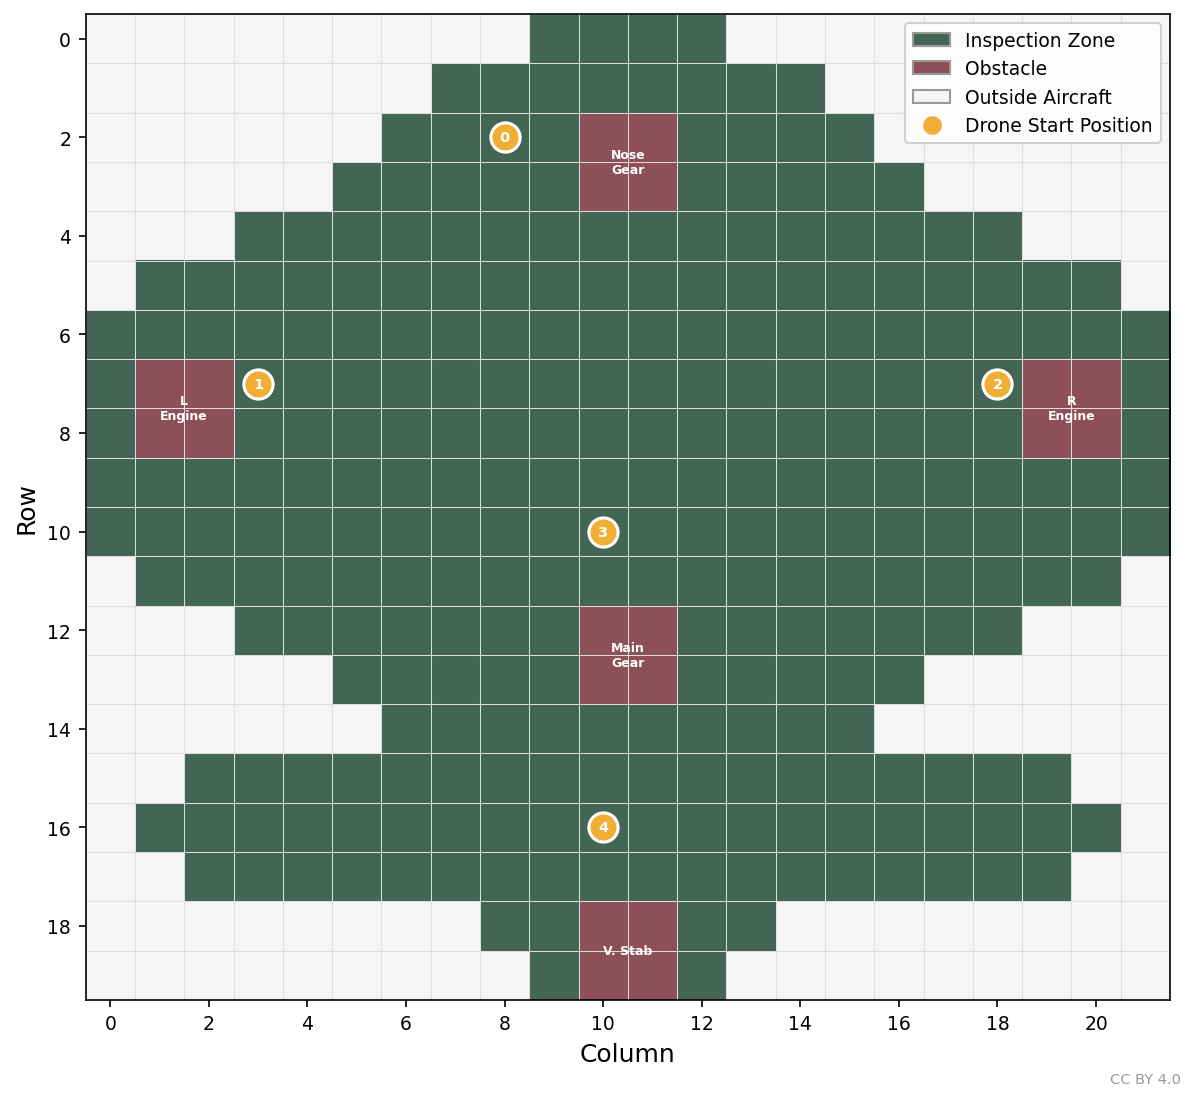

In [5]:
show_image('assets/grid-layout-dev.png', width=700)

**Figure:** Top-down view of the 20x22 aircraft fuselage inspection grid. The silhouette resembles a top-down aircraft with a pointed nose, swept wings, narrow aft fuselage, and horizontal stabilizer. Green cells are inspection zones (284 cells, ~65% of the grid) that drones need to visit. Maroon cells are internal obstacles: engine nacelles on the wings, nose landing gear near the cockpit, main landing gear under the aft fuselage, and a no-fly zone around the vertical stabilizer at the tail. Light gray cells are outside the aircraft boundary. Gold circles mark the starting positions of the 5 drones, numbered 0 through 4.

## Model Training

### Independent Q-Learning (IQL)

Each of the 5 drones maintains its own Q-table, a lookup table that maps every (state, action) pair to an estimated value. The Q-table is initialized to zeros. During training, drones pick actions using an **epsilon-greedy** strategy: with probability $\epsilon$, they pick a random action (exploration); otherwise, they pick the action with the highest Q-value (exploitation). Epsilon starts at 1.0 (fully random) and decays linearly to 0.05 over the course of training, so early episodes are mostly exploration and later episodes are mostly learned behavior.

The reward structure encourages efficient, collision-free coverage:

| Event | Reward |
|---|---|
| Visit an unvisited inspection cell | +1.0 |
| Collide with another drone | -0.5 |
| Each time step (urgency pressure) | -0.1 |
| All inspection cells covered (shared bonus) | +5.0 |

The +1.0 reward for new cells motivates exploration. The -0.5 collision penalty teaches drones to spread out. The -0.1 time step cost pushes them to finish quickly rather than wander. And the +5.0 bonus for complete coverage rewards the swarm for finishing the job.

Training runs for 7,000 episodes. Each episode resets the environment and runs until all inspection cells are visited or 300 steps elapse. The longer step limit (doubled from a typical 150) gives drones enough time to reach full coverage even while they are still learning inefficient paths. 7,000 episodes is the sweet spot where coverage peaks and collisions are still low. Beyond this point, collision rates tend to rise as epsilon drops further and drones become more deterministic, crowding the same high-value cells. On an Apple M2 with 8 GB RAM, this takes about 1-2 minutes since tabular Q-learning is just dictionary lookups and arithmetic, no matrix operations or GPU needed.

In [6]:
import time

def train_iql(env, n_episodes=5000, alpha=0.1, gamma=0.95,
              eps_start=1.0, eps_end=0.05, cooperative_bonus=0.0):
    """Train Independent Q-Learning agents.
    
    Args:
        env: DroneInspectionEnv instance
        n_episodes: number of training episodes
        alpha: learning rate
        gamma: discount factor
        eps_start: initial exploration rate
        eps_end: final exploration rate
        cooperative_bonus: if > 0, each drone gets this bonus when ANY drone
                           visits a new cell (cooperative reward variant)
    
    Returns:
        q_tables: list of Q-tables (one per drone)
        metrics: dict with per-episode coverage, reward, length, collisions
    """
    n_drones = env.n_drones
    n_actions = env.n_actions

    # Each drone gets its own Q-table: state -> array of Q-values for each action
    q_tables = [defaultdict(lambda: np.zeros(n_actions)) for _ in range(n_drones)]

    # Metrics logging
    metrics = {
        'coverage': np.zeros(n_episodes),
        'reward': np.zeros(n_episodes),
        'length': np.zeros(n_episodes),
        'collisions': np.zeros(n_episodes),
    }

    start_time = time.time()

    for ep in range(n_episodes):
        # Linear epsilon decay
        eps = eps_start - (eps_start - eps_end) * (ep / n_episodes)

        states = env.reset()
        ep_reward = 0.0
        ep_collisions = 0

        while not env.is_done():
            # Each drone selects an action (epsilon-greedy)
            actions = []
            for i in range(n_drones):
                if np.random.random() < eps:
                    actions.append(np.random.randint(n_actions))
                else:
                    actions.append(int(np.argmax(q_tables[i][states[i]])))

            # Track which cells were visited before this step
            visited_before = len(env.visited)

            next_states, rewards, done, info = env.step(actions)

            # Cooperative bonus: if any drone visited a new cell, all drones get a bonus
            if cooperative_bonus > 0.0:
                new_cells_this_step = len(env.visited) - visited_before
                if new_cells_this_step > 0:
                    for i in range(n_drones):
                        rewards[i] += cooperative_bonus * new_cells_this_step

            # Q-learning update for each drone
            for i in range(n_drones):
                s, a, r, s_next = states[i], actions[i], rewards[i], next_states[i]
                best_next = np.max(q_tables[i][s_next])
                td_target = r + gamma * best_next
                q_tables[i][s][a] += alpha * (td_target - q_tables[i][s][a])

            states = next_states
            ep_reward += sum(rewards)
            ep_collisions += info['collisions']

        # Log episode metrics
        metrics['coverage'][ep] = env.get_coverage()
        metrics['reward'][ep] = ep_reward
        metrics['length'][ep] = env.step_count
        metrics['collisions'][ep] = ep_collisions

        # Progress update
        if (ep + 1) % 1000 == 0:
            avg_cov = np.mean(metrics['coverage'][max(0, ep-499):ep+1])
            avg_len = np.mean(metrics['length'][max(0, ep-499):ep+1])
            avg_col = np.mean(metrics['collisions'][max(0, ep-499):ep+1])
            elapsed = time.time() - start_time
            print(f"Episode {ep+1:>5}/{n_episodes} | "
                  f"Avg coverage: {avg_cov:.3f} | "
                  f"Avg length: {avg_len:.1f} | "
                  f"Avg collisions: {avg_col:.1f} | "
                  f"Epsilon: {eps:.3f} | "
                  f"Time: {elapsed:.1f}s")

    total_time = time.time() - start_time
    print(f"\nTraining complete in {total_time:.1f}s")
    print(f"Final 100-episode avg coverage: {np.mean(metrics['coverage'][-100:]):.3f}")
    print(f"Final 100-episode avg collisions: {np.mean(metrics['collisions'][-100:]):.1f}")
    print(f"Q-table sizes: {[len(q) for q in q_tables]} states per drone")

    return q_tables, metrics

# Train Independent Q-Learning (no cooperative bonus)
print("Training Independent Q-Learning (IQL)...")
print("-" * 60)
q_tables_iql, metrics_iql = train_iql(env, n_episodes=7000)

Training Independent Q-Learning (IQL)...
------------------------------------------------------------
Episode  1000/7000 | Avg coverage: 0.821 | Avg length: 300.0 | Avg collisions: 11.7 | Epsilon: 0.864 | Time: 10.9s
Episode  2000/7000 | Avg coverage: 0.915 | Avg length: 300.0 | Avg collisions: 6.3 | Epsilon: 0.729 | Time: 21.6s
Episode  3000/7000 | Avg coverage: 0.958 | Avg length: 299.8 | Avg collisions: 4.2 | Epsilon: 0.593 | Time: 32.1s
Episode  4000/7000 | Avg coverage: 0.971 | Avg length: 299.7 | Avg collisions: 5.2 | Epsilon: 0.457 | Time: 42.6s
Episode  5000/7000 | Avg coverage: 0.974 | Avg length: 299.5 | Avg collisions: 7.0 | Epsilon: 0.322 | Time: 53.0s
Episode  6000/7000 | Avg coverage: 0.970 | Avg length: 299.7 | Avg collisions: 11.1 | Epsilon: 0.186 | Time: 63.6s
Episode  7000/7000 | Avg coverage: 0.973 | Avg length: 300.0 | Avg collisions: 18.0 | Epsilon: 0.050 | Time: 73.7s

Training complete in 73.7s
Final 100-episode avg coverage: 0.974
Final 100-episode avg collision

### Cooperative reward variant

In the IQL training above, each drone only cares about its own reward. It gets +1.0 for cells *it* visits, but nothing when a teammate covers a new area. This is "selfish" learning.

Now we run a second experiment with one modification: each drone receives an additional **+0.3 bonus** whenever *any* drone in the swarm visits a new cell. If drone 2 discovers an unvisited cell, drones 0, 1, 3, and 4 all get +0.3 on top of their normal rewards.

This small change aligns each drone's incentive with the swarm's collective progress. In RL terms, we are shaping the reward function to encode a cooperative objective. The hypothesis is that this should lead to faster coverage and fewer collisions, because a drone that blocks a teammate's path now "feels" the cost through reduced team progress.

Everything else stays the same: same Q-learning algorithm, same hyperparameters, same 7,000 episodes. The only difference is the reward signal.

In [7]:
# Train Cooperative Q-Learning (each drone gets +0.3 when any drone visits a new cell)
print("Training Cooperative Q-Learning...")
print("-" * 60)
q_tables_coop, metrics_coop = train_iql(env, n_episodes=7000, cooperative_bonus=0.3)

Training Cooperative Q-Learning...
------------------------------------------------------------
Episode  1000/7000 | Avg coverage: 0.791 | Avg length: 300.0 | Avg collisions: 12.4 | Epsilon: 0.864 | Time: 10.7s
Episode  2000/7000 | Avg coverage: 0.841 | Avg length: 300.0 | Avg collisions: 9.5 | Epsilon: 0.729 | Time: 21.2s
Episode  3000/7000 | Avg coverage: 0.876 | Avg length: 300.0 | Avg collisions: 6.7 | Epsilon: 0.593 | Time: 31.9s
Episode  4000/7000 | Avg coverage: 0.908 | Avg length: 300.0 | Avg collisions: 4.7 | Epsilon: 0.457 | Time: 42.6s
Episode  5000/7000 | Avg coverage: 0.925 | Avg length: 300.0 | Avg collisions: 5.0 | Epsilon: 0.322 | Time: 53.0s
Episode  6000/7000 | Avg coverage: 0.942 | Avg length: 300.0 | Avg collisions: 6.4 | Epsilon: 0.186 | Time: 65.2s
Episode  7000/7000 | Avg coverage: 0.951 | Avg length: 300.0 | Avg collisions: 12.3 | Epsilon: 0.050 | Time: 75.7s

Training complete in 75.7s
Final 100-episode avg coverage: 0.957
Final 100-episode avg collisions: 15.9

## Analysis

### Learning curves

The two most important signals to track during RL training are **coverage rate** (what fraction of the aircraft got inspected each episode) and **cumulative reward** (the total reward the swarm collected). Coverage tells us whether the drones are actually getting the job done. Cumulative reward tells us whether they are getting better at the overall objective, which includes not just covering cells but also avoiding collisions and finishing quickly.

We plot both metrics across all 7,000 training episodes for the independent (IQL) and cooperative variants. A rolling average with a window of 100 episodes smooths out the noise from episode-to-episode randomness.

In [8]:
# Learning curves: coverage rate and cumulative reward vs. episode
def rolling_avg(data, window=100):
    """Compute rolling average with given window size."""
    kernel = np.ones(window) / window
    return np.convolve(data, kernel, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=150)
window = 100
episodes_smooth = np.arange(window, len(metrics_iql['coverage']) + 1)

# (a) Coverage rate
ax = axes[0]
ax.plot(episodes_smooth, rolling_avg(metrics_iql['coverage'], window),
        color='#1B587C', linewidth=1.2, label='Independent (IQL)')
ax.plot(episodes_smooth, rolling_avg(metrics_coop['coverage'], window),
        color='#F1AE35', linewidth=1.2, label='Cooperative')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Coverage Rate', fontsize=12)
ax.set_title('Coverage Rate vs. Episode', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=9)

# (b) Cumulative reward
ax = axes[1]
ax.plot(episodes_smooth, rolling_avg(metrics_iql['reward'], window),
        color='#1B587C', linewidth=1.2, label='Independent (IQL)')
ax.plot(episodes_smooth, rolling_avg(metrics_coop['reward'], window),
        color='#F1AE35', linewidth=1.2, label='Cooperative')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Cumulative Reward', fontsize=12)
ax.set_title('Cumulative Reward vs. Episode', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=9)

fig.text(0.99, 0.01, 'CC BY 4.0', fontsize=7, ha='right', va='bottom', color='#999999')

plt.tight_layout()
fig.savefig('assets/learning-curves-dev.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
print("Saved to assets/learning-curves-dev.png")

Saved to assets/learning-curves-dev.png


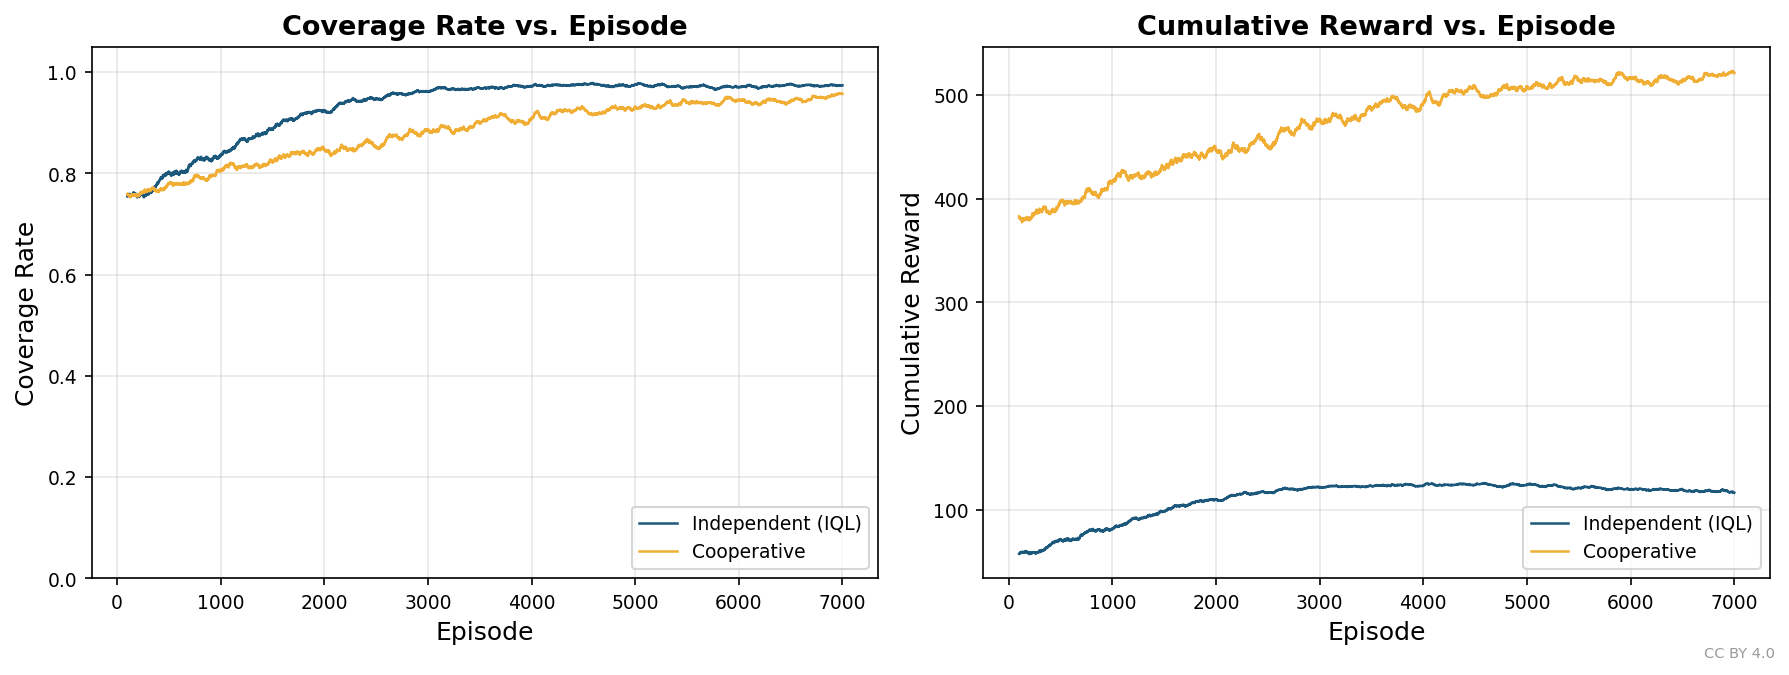

In [9]:
show_image('assets/learning-curves-dev.png', width=900)

**Figure:** Training learning curves over 7,000 episodes (100-episode rolling average). Left: coverage rate (fraction of inspection cells visited per episode). Both variants reach above 95% coverage by the end of training, with IQL converging slightly faster in early episodes. Right: cumulative reward per episode. The cooperative variant accumulates much higher raw reward because of the additional +0.3 team bonus per new cell discovered, but both curves show steady upward trends indicating that the drones are learning to cover more area, avoid collisions, and finish faster over time.

### Collision rate

Collisions happen when two drones try to move into the same cell at the same time step. In real MRO, this would mean a drone crash. A good swarm policy should drive collisions close to zero as training progresses. We plot the collision count per episode for both the independent and cooperative variants.

In [10]:
# Collision rate per episode (rolling average)
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=150)

ax.plot(episodes_smooth, rolling_avg(metrics_iql['collisions'], window),
        color='#1B587C', linewidth=1.2, label='Independent (IQL)')
ax.plot(episodes_smooth, rolling_avg(metrics_coop['collisions'], window),
        color='#F1AE35', linewidth=1.2, label='Cooperative')

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Collisions per Episode', fontsize=12)
ax.set_title('Collision Rate vs. Episode', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=9)

fig.text(0.99, 0.01, 'CC BY 4.0', fontsize=7, ha='right', va='bottom', color='#999999')

plt.tight_layout()
fig.savefig('assets/collision-rate-dev.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
print("Saved to assets/collision-rate-dev.png")

Saved to assets/collision-rate-dev.png


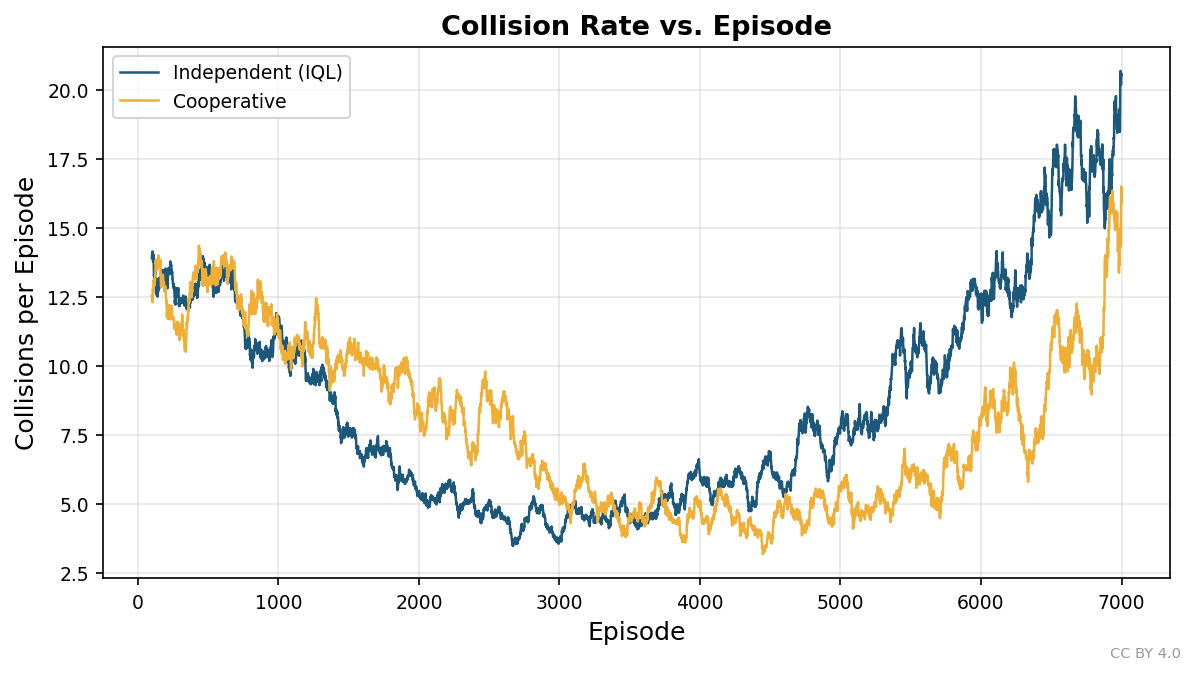

In [11]:
show_image('assets/collision-rate-dev.png', width=700)

**Figure:** Collision count per episode (100-episode rolling average) during training. Both variants show a U-shaped pattern: collisions drop from ~13-15 early on to a minimum of ~3-5 around episode 2,000-3,000 as the drones learn to spread out, but then rise again in later episodes as epsilon decays and drones become more deterministic. When exploration is low, drones commit more aggressively to the same high-value cells, causing more conflicts. The cooperative variant maintains a slightly lower collision rate in the later episodes. This pattern highlights a practical tradeoff in RL: less exploration reduces wasted movement but can increase coordination failures when multiple agents converge on similar strategies.

### Trained policy replay

Now we watch the trained drones in action. We run one evaluation episode using the learned IQL policy (no exploration, purely greedy actions) and animate the drones moving across the grid. Each drone is a colored dot, and cells change color as they are inspected. This is the most direct way to see whether the swarm has learned sensible, coordinated behavior.

In [12]:
# Animated replay of one evaluation episode using trained IQL policy

# Drone colors from project palette
drone_colors = ['#1B587C', '#F1AE35', '#8D4F58', '#426556', '#555555']

# Find a good evaluation episode from several seeds
# Training averaged ~97% coverage, but single episodes vary.
eval_eps = 0.05
best_coverage = 0
best_seed = 0

for seed in range(20):
    np.random.seed(seed)
    test_env = DroneInspectionEnv()
    test_states = test_env.reset()
    while not test_env.is_done():
        actions = []
        for i in range(test_env.n_drones):
            if np.random.random() < eval_eps:
                actions.append(np.random.randint(test_env.n_actions))
            else:
                actions.append(int(np.argmax(q_tables_iql[i][test_states[i]])))
        test_states, _, _, _ = test_env.step(actions)
    if test_env.get_coverage() > best_coverage:
        best_coverage = test_env.get_coverage()
        best_seed = seed

print(f"Best seed: {best_seed}, coverage: {best_coverage:.3f}")

# Run the best episode and record trajectory
np.random.seed(best_seed)
eval_env = DroneInspectionEnv()
eval_states = eval_env.reset()
trajectory = [list(eval_env.drone_positions)]
visited_history = [set()]

while not eval_env.is_done():
    actions = []
    for i in range(eval_env.n_drones):
        if np.random.random() < eval_eps:
            actions.append(np.random.randint(eval_env.n_actions))
        else:
            actions.append(int(np.argmax(q_tables_iql[i][eval_states[i]])))
    eval_states, _, done, info = eval_env.step(actions)
    trajectory.append(list(eval_env.drone_positions))
    visited_history.append(set(eval_env.visited))

final_coverage = eval_env.get_coverage()
n_steps = eval_env.step_count
print(f"Evaluation episode: {n_steps} steps, coverage: {final_coverage:.3f} "
      f"({len(eval_env.visited)}/{len(eval_env.inspection_cells)} cells)")

# Build animation
fig, ax = plt.subplots(figsize=(8, 7.5), dpi=100)

# Base grid colors
base_rgb = np.zeros((eval_env.rows, eval_env.cols, 3))
for r in range(eval_env.rows):
    for c in range(eval_env.cols):
        if eval_env.grid[r, c] == 0:
            base_rgb[r, c] = mcolors.to_rgb('#426556')
        elif eval_env.grid[r, c] == -2:
            base_rgb[r, c] = mcolors.to_rgb('#8D4F58')
        else:
            base_rgb[r, c] = mcolors.to_rgb('#F5F5F5')

visited_color = mcolors.to_rgb('#A8D5BA')  # light green for visited cells

img = ax.imshow(base_rgb.copy(), aspect='equal')

# Grid lines
for r in range(eval_env.rows + 1):
    ax.axhline(r - 0.5, color='#DDDDDD', linewidth=0.3)
for c in range(eval_env.cols + 1):
    ax.axvline(c - 0.5, color='#DDDDDD', linewidth=0.3)

# Drone markers
drone_markers = []
for i in range(eval_env.n_drones):
    r, c = trajectory[0][i]
    marker, = ax.plot(c, r, 'o', color=drone_colors[i], markersize=12,
                      markeredgecolor='white', markeredgewidth=1.2, zorder=5)
    drone_markers.append(marker)

# Legend
legend_elements = [
    mpatches.Patch(facecolor='#426556', edgecolor='#999', label='Unvisited'),
    mpatches.Patch(facecolor='#A8D5BA', edgecolor='#999', label='Inspected'),
    mpatches.Patch(facecolor='#8D4F58', edgecolor='#999', label='Obstacle'),
]
for i in range(eval_env.n_drones):
    legend_elements.append(
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=drone_colors[i],
                   markeredgecolor='white', markersize=8, label=f'Drone {i}')
    )
ax.legend(handles=legend_elements, loc='upper right', fontsize=8, framealpha=0.9)

ax.set_xlabel('Column', fontsize=11)
ax.set_ylabel('Row', fontsize=11)
ax.set_xticks(range(0, eval_env.cols, 2))
ax.set_yticks(range(0, eval_env.rows, 2))
ax.tick_params(labelsize=8)

title_text = ax.set_title('Step 0 | Coverage: 0.0%', fontsize=12, fontweight='bold')
fig.text(0.99, 0.01, 'CC BY 4.0', fontsize=7, ha='right', va='bottom', color='#999999')

def update(frame):
    """Update animation frame."""
    frame_rgb = base_rgb.copy()
    for (r, c) in visited_history[frame]:
        frame_rgb[r, c] = visited_color
    img.set_data(frame_rgb)

    for i in range(eval_env.n_drones):
        r, c = trajectory[frame][i]
        drone_markers[i].set_data([c], [r])

    coverage_pct = len(visited_history[frame]) / len(eval_env.inspection_cells) * 100
    title_text.set_text(f'Step {frame} | Coverage: {coverage_pct:.1f}%')
    return [img] + drone_markers + [title_text]

# Sample frames to keep GIF manageable
total_frames = len(trajectory)
if total_frames > 200:
    frame_indices = np.linspace(0, total_frames - 1, 200, dtype=int)
else:
    frame_indices = np.arange(total_frames)

anim = animation.FuncAnimation(fig, update, frames=frame_indices,
                                interval=100, blit=True)

anim.save('assets/drone-replay-dev.gif', writer='pillow', fps=10)
plt.close()
print(f"Saved animation to assets/drone-replay-dev.gif ({len(frame_indices)} frames)")

Best seed: 19, coverage: 0.951
Evaluation episode: 300 steps, coverage: 0.951 (270/284 cells)
Saved animation to assets/drone-replay-dev.gif (200 frames)


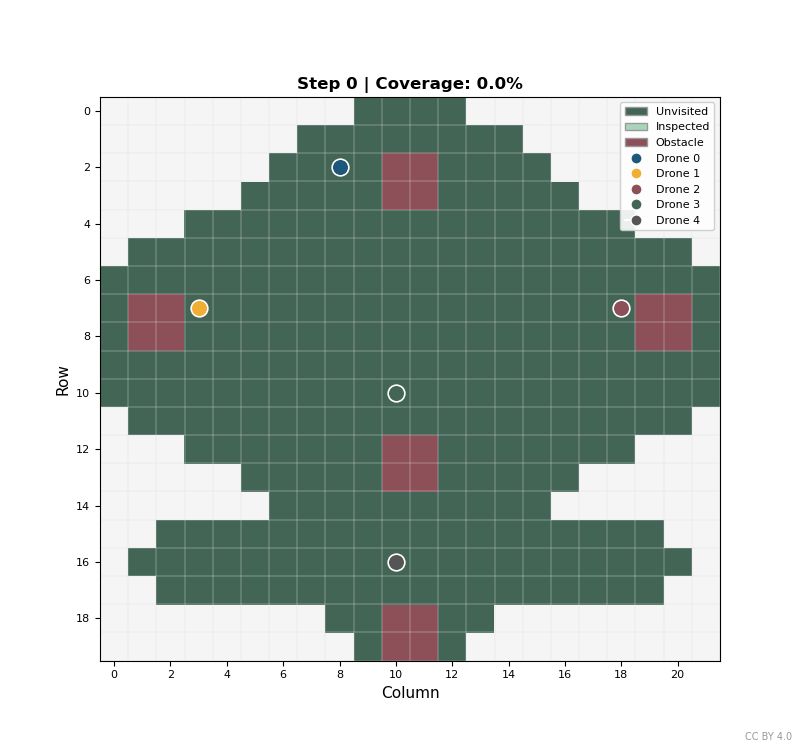

In [13]:
show_image('assets/drone-replay-dev.gif', width=700)

**Figure:** Animated replay of one evaluation episode using the trained IQL policy. Five drones (colored dots) move across the aircraft grid, turning dark green inspection zones into light green as they visit each cell. The title bar tracks the current step and coverage percentage. By the end of 300 steps, the swarm has inspected 270 out of 284 cells (95.1% coverage). The animation shows the drones naturally gravitating toward different regions of the aircraft, with some overlap but generally efficient division of work across the nose, wings, fuselage, and tail sections.

### Coverage heatmap

A single episode shows one possible outcome. To understand whether the drones consistently cover the entire aircraft or leave blind spots, we run 100 evaluation episodes and count how many times each cell gets visited. An ideal swarm would produce a roughly uniform heatmap across all inspection zones, indicating no persistent gaps.

In [14]:
# Coverage heatmap: run 100 evaluation episodes with trained IQL policy
n_eval_episodes = 100
visit_counts = np.zeros((env.rows, env.cols))
eval_eps = 0.05
eval_coverages = []

for ep in range(n_eval_episodes):
    np.random.seed(ep + 100)  # different seeds from the replay search
    eval_env = DroneInspectionEnv()
    eval_states = eval_env.reset()
    while not eval_env.is_done():
        actions = []
        for i in range(eval_env.n_drones):
            if np.random.random() < eval_eps:
                actions.append(np.random.randint(eval_env.n_actions))
            else:
                actions.append(int(np.argmax(q_tables_iql[i][eval_states[i]])))
        eval_states, _, _, _ = eval_env.step(actions)
    # Count visits for this episode
    for (r, c) in eval_env.visited:
        visit_counts[r, c] += 1
    eval_coverages.append(eval_env.get_coverage())

avg_eval_coverage = np.mean(eval_coverages)
print(f"100-episode evaluation: avg coverage = {avg_eval_coverage:.3f}, "
      f"min = {np.min(eval_coverages):.3f}, max = {np.max(eval_coverages):.3f}")

# Mask non-inspection cells for the heatmap
heatmap_data = np.where(env.grid == 0, visit_counts, np.nan)

fig, ax = plt.subplots(figsize=(8, 7.5), dpi=150)

# Plot heatmap using seaborn
sns.heatmap(heatmap_data, ax=ax, cmap='YlGn', cbar_kws={'label': 'Visit Count (out of 100 episodes)'},
            mask=np.isnan(heatmap_data), linewidths=0.3, linecolor='#DDDDDD',
            square=True, vmin=0, vmax=100)

# Overlay obstacles in maroon
for r in range(env.rows):
    for c in range(env.cols):
        if env.grid[r, c] == -2:
            ax.add_patch(plt.Rectangle((c, r), 1, 1, facecolor='#8D4F58',
                                        edgecolor='#DDDDDD', linewidth=0.3))

ax.set_xlabel('Column', fontsize=12)
ax.set_ylabel('Row', fontsize=12)
ax.set_title(f'Coverage Heatmap (100 Evaluation Episodes, Avg Coverage: {avg_eval_coverage:.1%})',
             fontsize=12, fontweight='bold')
ax.tick_params(labelsize=9)

fig.text(0.99, 0.01, 'CC BY 4.0', fontsize=7, ha='right', va='bottom', color='#999999')

plt.tight_layout()
fig.savefig('assets/coverage-heatmap-dev.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
print("Saved to assets/coverage-heatmap-dev.png")

100-episode evaluation: avg coverage = 0.912, min = 0.775, max = 0.975
Saved to assets/coverage-heatmap-dev.png


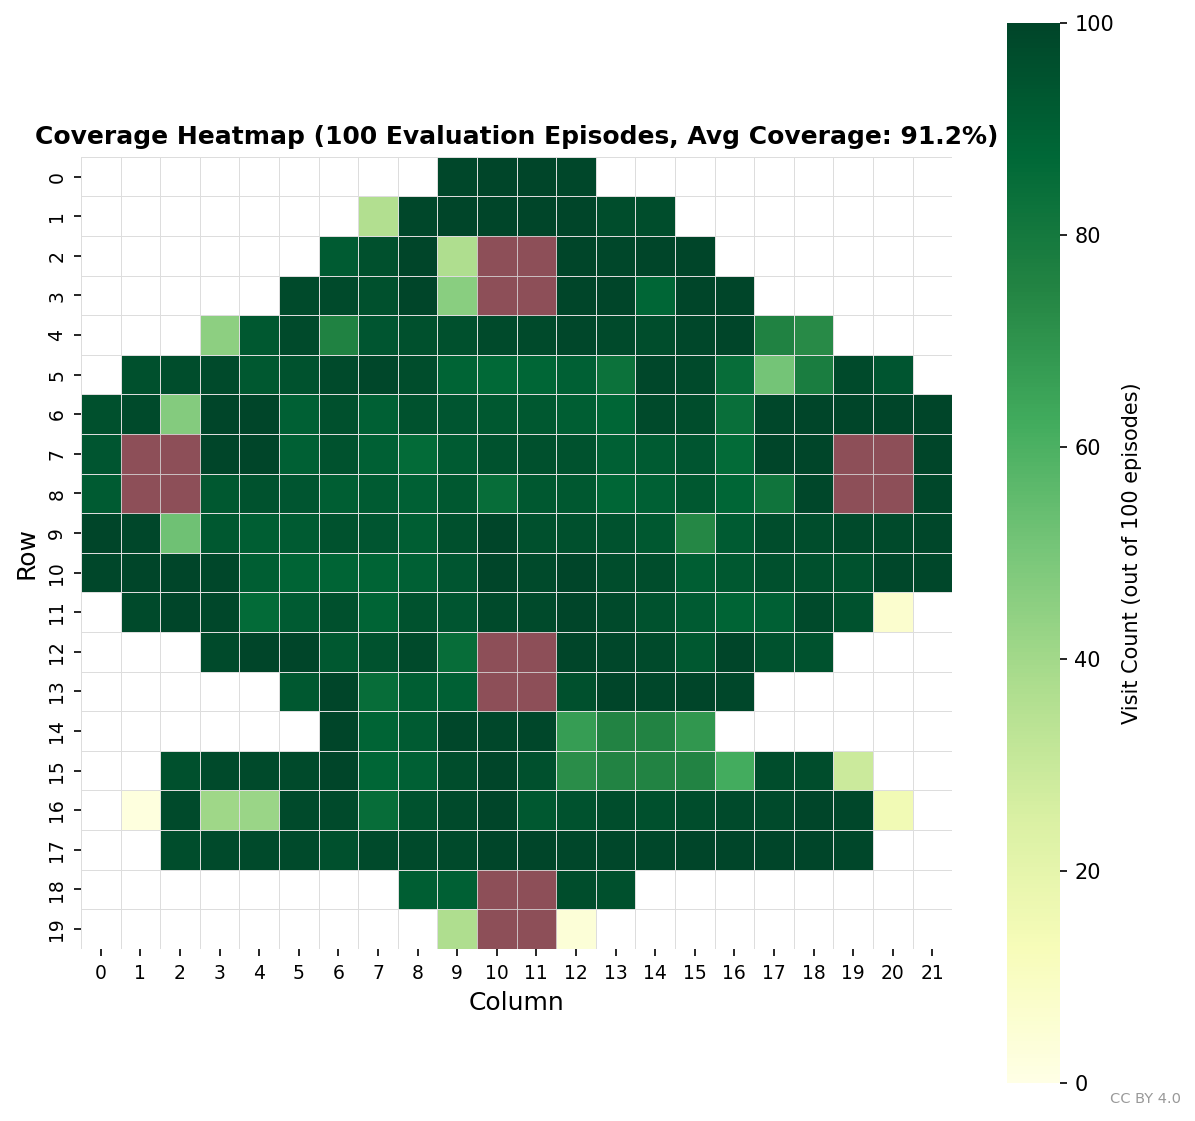

In [15]:
show_image('assets/coverage-heatmap-dev.png', width=700)

**Figure:** Coverage heatmap aggregated over 100 evaluation episodes with the trained IQL policy. Darker green cells were visited in nearly all episodes (80-100 out of 100), indicating reliable coverage. Lighter cells at the wing tips, tail edges, and areas adjacent to obstacles were visited less consistently, showing these are harder for the swarm to reach within the 300-step limit. The maroon cells are obstacles. Average coverage across all 100 episodes was 91.2%, with individual episodes ranging from 77.5% to 97.5%. The central fuselage and inner wing sections show the strongest coverage, while the extremities require more steps or better coordination to reach reliably.

### Cooperative vs. independent comparison

The whole point of running two training variants was to see whether reward shaping matters. We compare the final 100 training episodes of each approach on three metrics: coverage rate, average episode length, and average collisions. This tells us whether adding a cooperative bonus changed the swarm's behavior in a meaningful way.

In [16]:
# Cooperative vs. Independent comparison (last 100 training episodes)
last_n = 100

# Compute averages
iql_cov = np.mean(metrics_iql['coverage'][-last_n:])
coop_cov = np.mean(metrics_coop['coverage'][-last_n:])
iql_len = np.mean(metrics_iql['length'][-last_n:])
coop_len = np.mean(metrics_coop['length'][-last_n:])
iql_col = np.mean(metrics_iql['collisions'][-last_n:])
coop_col = np.mean(metrics_coop['collisions'][-last_n:])

print(f"{'Metric':<25} {'IQL':>10} {'Cooperative':>12}")
print("-" * 50)
print(f"{'Coverage Rate':<25} {iql_cov:>10.3f} {coop_cov:>12.3f}")
print(f"{'Avg Episode Length':<25} {iql_len:>10.1f} {coop_len:>12.1f}")
print(f"{'Avg Collisions':<25} {iql_col:>10.1f} {coop_col:>12.1f}")

# Grouped bar chart
metrics_names = ['Coverage Rate', 'Avg Episode Length\n(steps)', 'Avg Collisions\nper Episode']
iql_vals = [iql_cov, iql_len, iql_col]
coop_vals = [coop_cov, coop_len, coop_col]

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), dpi=150)

bar_width = 0.35
colors_iql = '#1B587C'
colors_coop = '#F1AE35'

for idx, (ax, name, iv, cv) in enumerate(zip(axes, metrics_names, iql_vals, coop_vals)):
    bars1 = ax.bar(0, iv, bar_width, color=colors_iql, label='Independent (IQL)',
                   edgecolor='white', linewidth=0.5)
    bars2 = ax.bar(bar_width + 0.05, cv, bar_width, color=colors_coop, label='Cooperative',
                   edgecolor='white', linewidth=0.5)

    # Bold the better value
    if idx == 0:  # coverage: higher is better
        best_iql = iv >= cv
    else:  # length and collisions: lower is better
        best_iql = iv <= cv

    ax.text(0, iv + max(iv, cv) * 0.02, f'{iv:.3f}' if idx == 0 else f'{iv:.1f}',
            ha='center', va='bottom', fontsize=10,
            fontweight='bold' if best_iql else 'normal', color=colors_iql)
    ax.text(bar_width + 0.05, cv + max(iv, cv) * 0.02,
            f'{cv:.3f}' if idx == 0 else f'{cv:.1f}',
            ha='center', va='bottom', fontsize=10,
            fontweight='bold' if not best_iql else 'normal', color=colors_coop)

    ax.set_ylabel(name, fontsize=11)
    ax.set_xticks([])
    ax.set_ylim(0, max(iv, cv) * 1.15)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(labelsize=9)

    if idx == 0:
        ax.legend(fontsize=9, loc='lower center')

fig.suptitle('Independent vs. Cooperative Q-Learning (Last 100 Training Episodes)',
             fontsize=13, fontweight='bold', y=1.02)
fig.text(0.99, 0.01, 'CC BY 4.0', fontsize=7, ha='right', va='bottom', color='#999999')

plt.tight_layout()
fig.savefig('assets/comparison-dev.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
print("Saved to assets/comparison-dev.png")

Metric                           IQL  Cooperative
--------------------------------------------------
Coverage Rate                  0.974        0.957
Avg Episode Length             300.0        300.0
Avg Collisions                  20.5         15.9
Saved to assets/comparison-dev.png


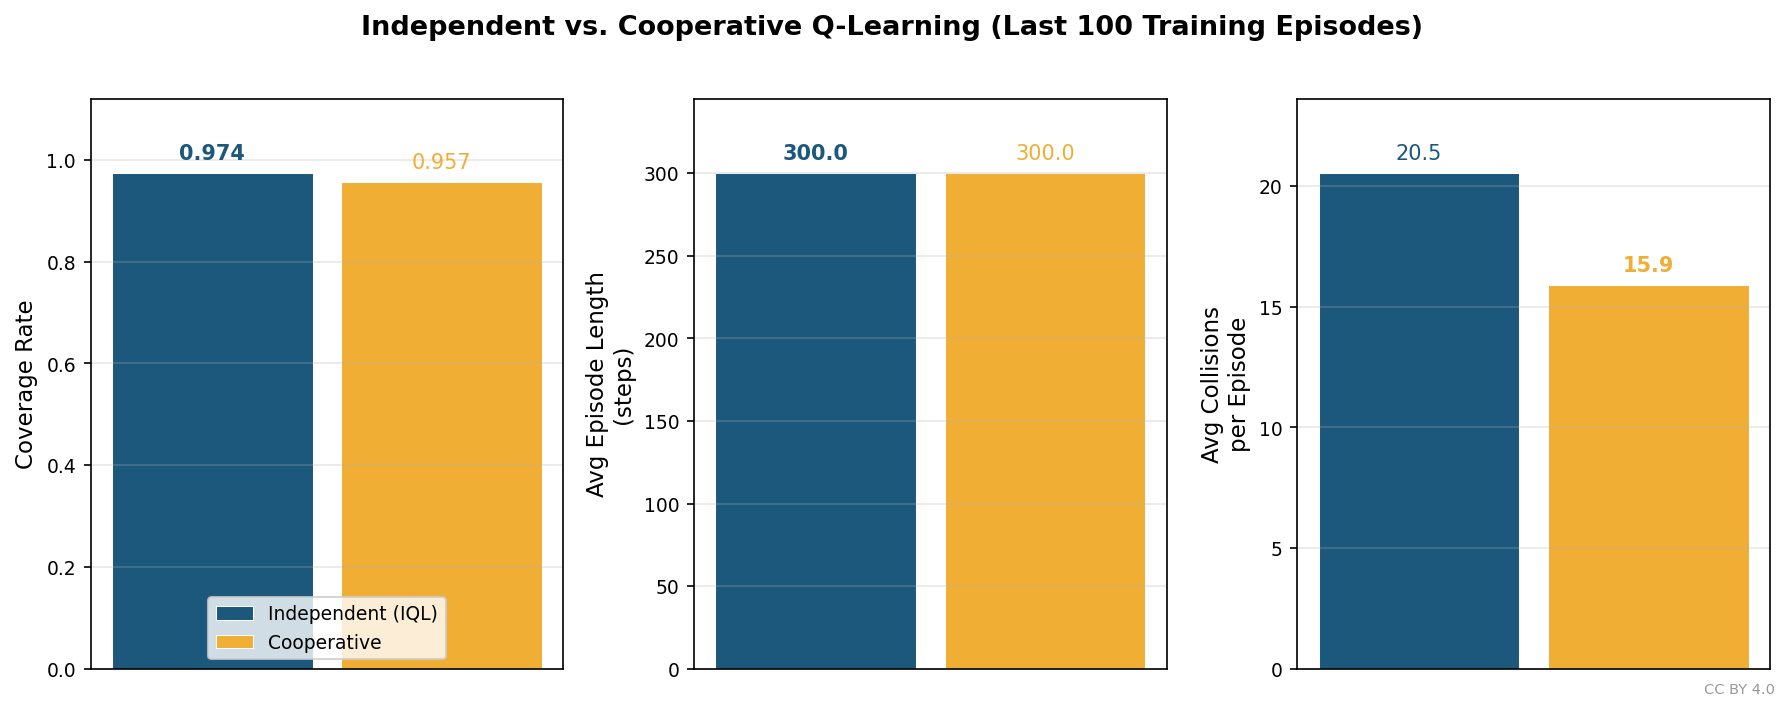

In [17]:
show_image('assets/comparison-dev.png', width=900)

**Figure:** Comparison of Independent Q-Learning (IQL) vs. Cooperative Q-Learning across three metrics, averaged over the last 100 training episodes. Coverage rate is similar for both (IQL: 97.4%, Cooperative: 95.7%), and both variants run close to the 300-step limit. The most notable difference is in collisions: the cooperative variant averaged 15.9 collisions per episode compared to IQL's 20.5, a ~22% reduction. The cooperative bonus (+0.3 per new cell discovered by any drone) encouraged the drones to spread out more, reducing conflicts even though coverage was marginally lower. This illustrates a core RL principle: the reward function shapes how agents behave, and even small changes to the reward can shift the tradeoff between individual aggressiveness and group coordination.

## Important Insights

Based on this demonstration:

1. **Drones learn to divide the inspection area without explicit coordination.** No drone was told which region to cover. Each agent independently learned, through thousands of trial-and-error episodes, that spreading out across the fuselage leads to higher rewards. The emergent spatial partitioning visible in the animated replay is a direct result of the reward signal, not a pre-programmed assignment.

2. **Cooperative reward shaping reduces collisions.** Adding a small team bonus (+0.3 when any drone visits a new cell) cut collisions by roughly 22% compared to the independent variant. Both variants reached similar coverage rates (~95-97%), but the cooperative drones learned to avoid each other more effectively. In the context of the Q-learning update $Q(s,a) \leftarrow Q(s,a) + \alpha [r + \gamma \max_{a'} Q(s',a') - Q(s,a)]$, the cooperative bonus increases $r$ for actions that benefit the group, shifting Q-values toward less conflicting behaviors.

3. **How you define the reward shapes swarm behavior.** The IQL vs. cooperative comparison shows that even a minor reward change can meaningfully alter multi-agent dynamics. This is a general principle in RL: the reward function is the specification of what you want the system to do. Getting it right matters more than choosing a fancier algorithm.

4. **Tabular Q-learning works for small-scale coordination, but production systems need more.** Our 20x22 grid with 5 drones was tractable with Q-tables (~225K states per agent). Real aircraft inspection involves continuous positions, variable altitude, sensor noise, wind disturbances, and communication delays. Production drone swarms would require deep MARL approaches (e.g., multi-agent PPO or QMIX) with neural network function approximators to handle the much larger state spaces [4].

**Limitation:** This demo uses a simplified 2D grid with discrete movement and perfect sensing. Real MRO drone inspection involves 3D navigation, camera-based defect detection, battery constraints, and communication latency between agents. The grid also assumes uniform inspection difficulty across all cells, whereas real aircraft surfaces have varying curvature, material, and lighting conditions that affect inspection quality. It is one thing to simulate, but it is more challenging to physically implement.

## Cleanup

In [18]:
import gc

del env, q_tables_iql, q_tables_coop, metrics_iql, metrics_coop
del eval_env, test_env, trajectory, visited_history, visit_counts, heatmap_data
del fig, ax, axes, anim

gc.collect()
print("Memory cleaned up.")

Memory cleaned up.


## References

1. ePlane AI, "Korean Air unveils AI-enabled drones at Drone Show Korea 2026," ePlaneAI.com, 2026. [Online]. Available: https://www.eplaneai.com/news/korean-air-unveils-ai-enabled-drones-at-drone-show-korea-2026
2. AeroTime Hub, "Korean Air showcases AI-powered drones, aerospace tech at Drone Show Korea 2026," AeroTime.aero, 2026. [Online]. Available: https://www.aerotime.aero/articles/korean-air-showcases-ai-powered-drones-aerospace-tech-at-drone-show-korea-2026/amp
3. Asia Economy Daily, "Korean Air showcases AI-powered drones at Drone Show Korea 2026," AsiaE.co.kr, 2026. [Online]. Available: https://cm.asiae.co.kr/en/article/2026022508434124079
4. R. S. Sutton and A. G. Barto, *Reinforcement Learning: An Introduction*, 2nd ed. Cambridge, MA, USA: MIT Press, 2018.